# B+ Tree Step-by-Step Builder (Order = 4)

This notebook shows every insertion step for the same sequence used in your report:

[10, 20, 5, 15, 25, 3, 7, 12, 18, 30, 35, 2, 8, 22]

What you will get:
- Full step-by-step construction from empty tree
- Split event details (leaf copy-up and internal promote-up)
- Tree structure at each step
- Leaf linked-list chain at each step
- Inline figure output only (no files are saved)

In [1]:
import os
import sys
from collections import deque
from IPython.display import Image, display

sys.path.insert(0, os.path.abspath('.'))

from database.bplustree import BPlusTree


class TracedBPlusTree(BPlusTree):
    def __init__(self, order=4):
        super().__init__(order=order)
        self.trace_events = []

    def _split_child(self, parent, index):
        child = parent.children[index]
        child_before = child.keys.copy()
        was_leaf = child.is_leaf

        super()._split_child(parent, index)

        separator = parent.keys[index]
        left_after = parent.children[index].keys.copy()
        right_after = parent.children[index + 1].keys.copy()

        self.trace_events.append({
            'type': 'leaf-copy-up' if was_leaf else 'internal-promote-up',
            'child_before': child_before,
            'separator_to_parent': separator,
            'left_after': left_after,
            'right_after': right_after,
        })


print('Setup complete. TracedBPlusTree is ready.')

Setup complete. TracedBPlusTree is ready.


In [2]:
def node_label(node):
    prefix = 'L' if node.is_leaf else 'I'
    return f"{prefix}{node.keys}"


def get_levels(tree):
    levels = []
    queue = deque([(tree.root, 0)])

    while queue:
        node, depth = queue.popleft()

        if depth == len(levels):
            levels.append([])

        levels[depth].append(node_label(node))

        if not node.is_leaf:
            for child in node.children:
                queue.append((child, depth + 1))

    return levels


def get_leaf_chain(tree):
    node = tree.root
    while not node.is_leaf:
        node = node.children[0]

    chain = []
    while node is not None:
        chain.append(node.keys.copy())
        node = node.next

    return chain


def print_tree_state(tree):
    levels = get_levels(tree)
    for depth, labels in enumerate(levels):
        print(f"Level {depth}: " + '  |  '.join(labels))

    chain = get_leaf_chain(tree)
    print('Leaf chain:', ' -> '.join(str(part) for part in chain))


def show_inline_graph(tree, title):
    try:
        dot = tree.visualize_tree(title=title)
        png_data = dot.pipe(format='png')
        display(Image(data=png_data))
        return True
    except Exception as exc:
        print(f"(Inline graph unavailable: {exc})")
        return False


print('Helper functions ready.')

Helper functions ready.


Running full construction trace...
Sequence: [10, 20, 5, 15, 25, 3, 7, 12, 18, 30, 35, 2, 8, 22]

Step 01: insert 10
Split event: none
Level 0: L[10]
Leaf chain: [10]


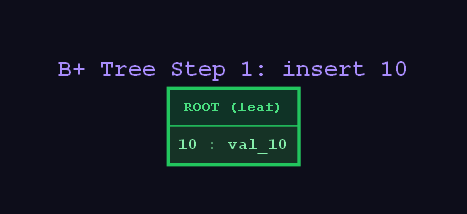


Step 02: insert 20
Split event: none
Level 0: L[10, 20]
Leaf chain: [10, 20]


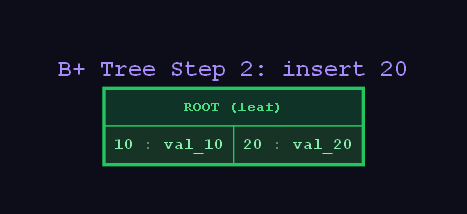


Step 03: insert 5
Split event: none
Level 0: L[5, 10, 20]
Leaf chain: [5, 10, 20]


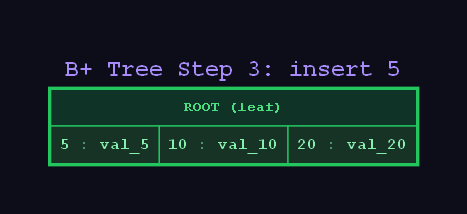


Step 04: insert 15
Split event 1: Leaf split (copy-up)
  child before split : [5, 10, 20]
  separator to parent: 10
  left after split   : [5]
  right after split  : [10, 20]
Level 0: I[10]
Level 1: L[5]  |  L[10, 15, 20]
Leaf chain: [5] -> [10, 15, 20]


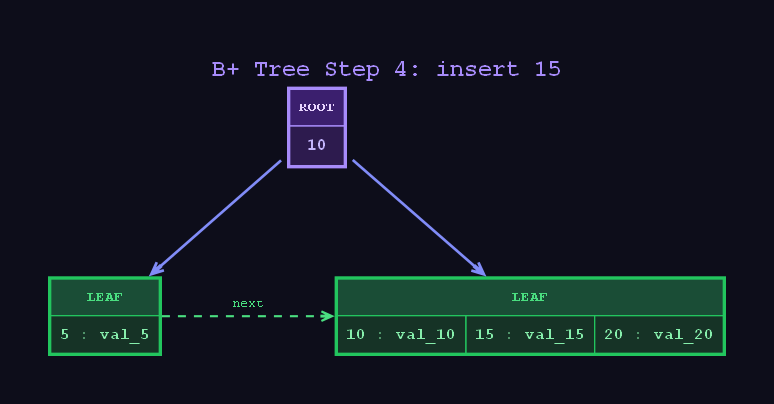


Step 05: insert 25
Split event 1: Leaf split (copy-up)
  child before split : [10, 15, 20]
  separator to parent: 15
  left after split   : [10]
  right after split  : [15, 20]
Level 0: I[10, 15]
Level 1: L[5]  |  L[10]  |  L[15, 20, 25]
Leaf chain: [5] -> [10] -> [15, 20, 25]


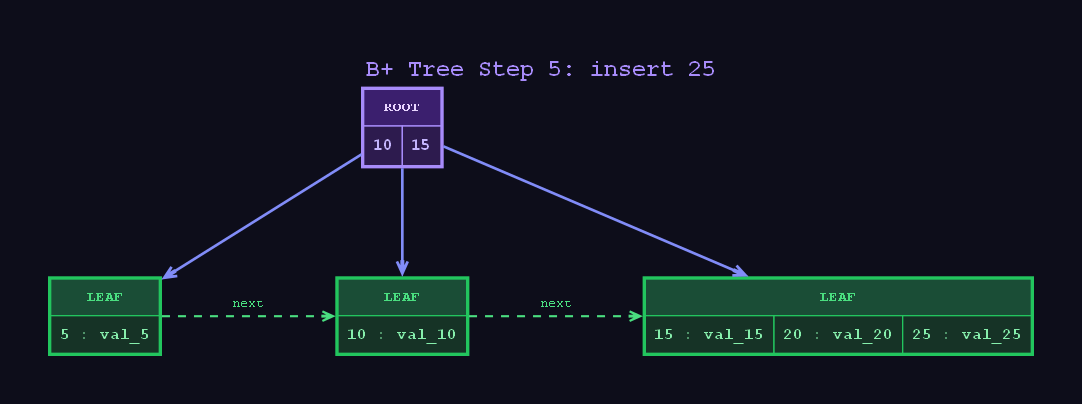


Step 06: insert 3
Split event: none
Level 0: I[10, 15]
Level 1: L[3, 5]  |  L[10]  |  L[15, 20, 25]
Leaf chain: [3, 5] -> [10] -> [15, 20, 25]


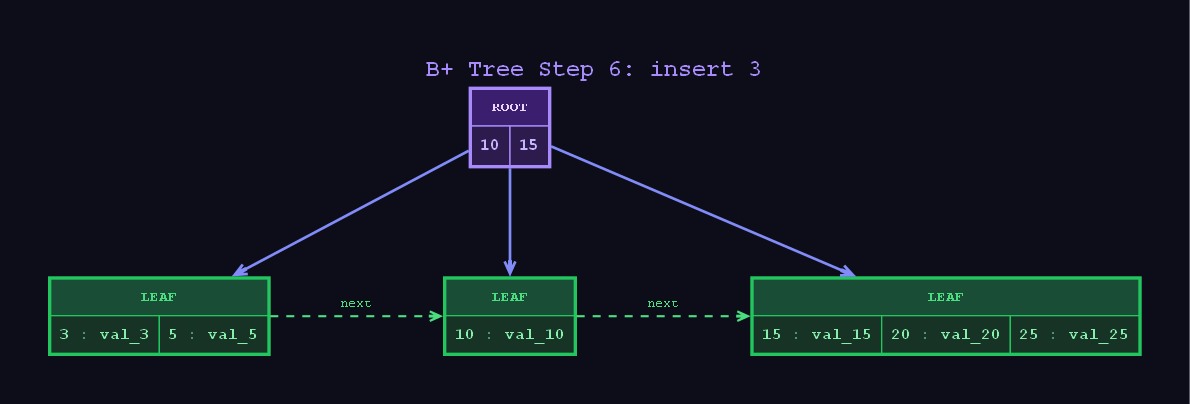


Step 07: insert 7
Split event: none
Level 0: I[10, 15]
Level 1: L[3, 5, 7]  |  L[10]  |  L[15, 20, 25]
Leaf chain: [3, 5, 7] -> [10] -> [15, 20, 25]


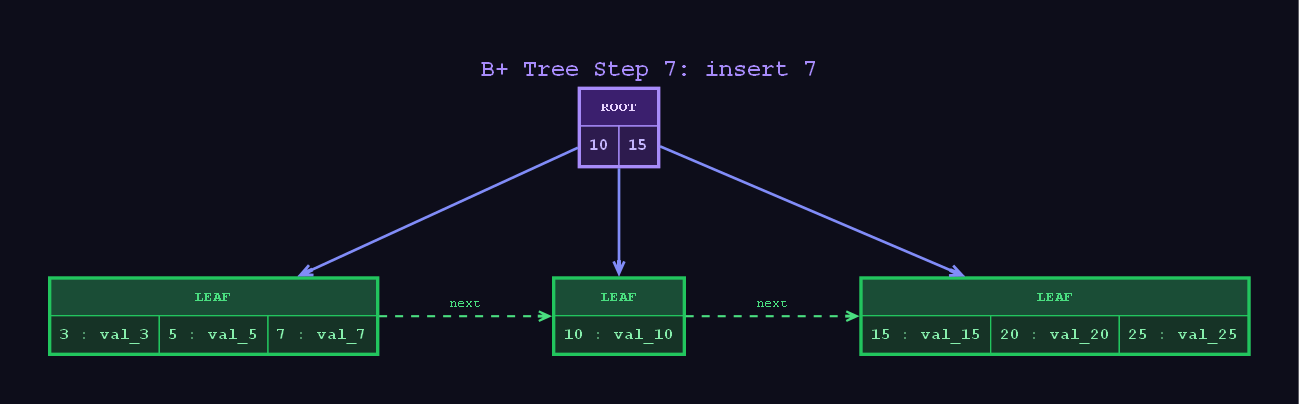


Step 08: insert 12
Split event: none
Level 0: I[10, 15]
Level 1: L[3, 5, 7]  |  L[10, 12]  |  L[15, 20, 25]
Leaf chain: [3, 5, 7] -> [10, 12] -> [15, 20, 25]


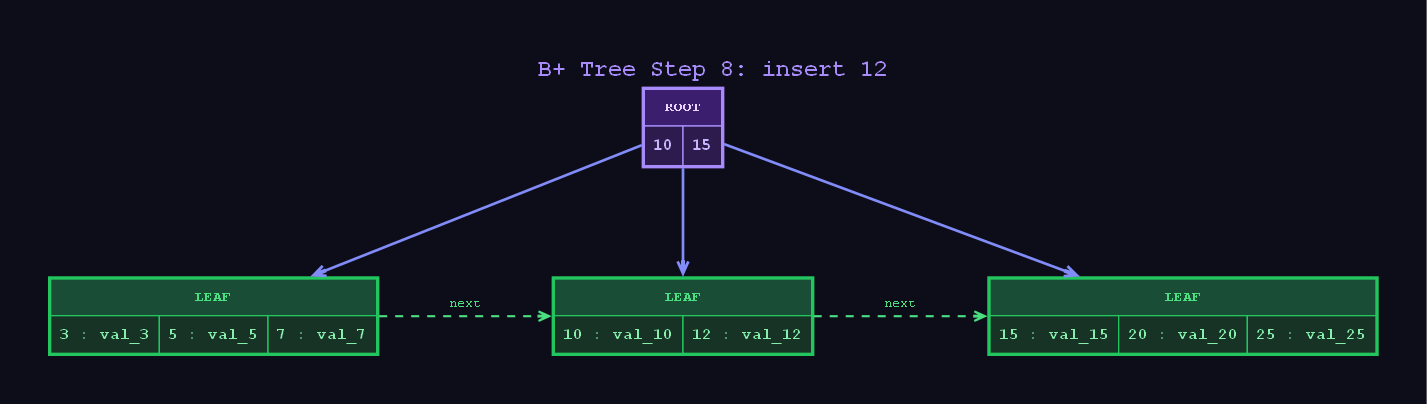


Step 09: insert 18
Split event 1: Leaf split (copy-up)
  child before split : [15, 20, 25]
  separator to parent: 20
  left after split   : [15]
  right after split  : [20, 25]
Level 0: I[10, 15, 20]
Level 1: L[3, 5, 7]  |  L[10, 12]  |  L[15, 18]  |  L[20, 25]
Leaf chain: [3, 5, 7] -> [10, 12] -> [15, 18] -> [20, 25]


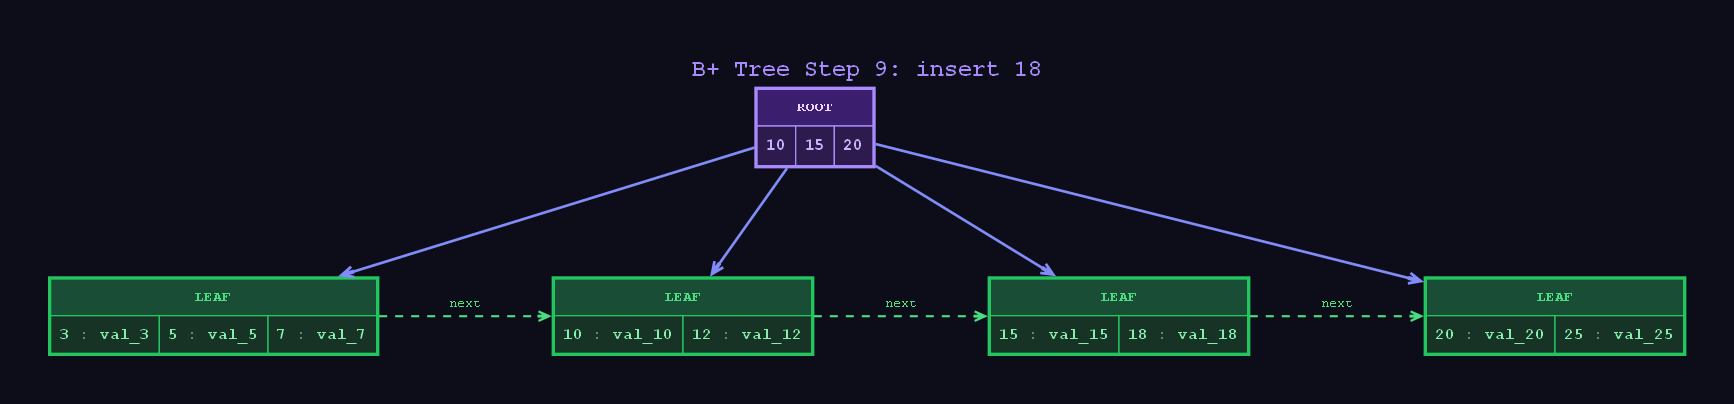


Step 10: insert 30
Split event 1: Internal split (promote-up)
  child before split : [10, 15, 20]
  separator to parent: 15
  left after split   : [10]
  right after split  : [20]
Level 0: I[15]
Level 1: I[10]  |  I[20]
Level 2: L[3, 5, 7]  |  L[10, 12]  |  L[15, 18]  |  L[20, 25, 30]
Leaf chain: [3, 5, 7] -> [10, 12] -> [15, 18] -> [20, 25, 30]


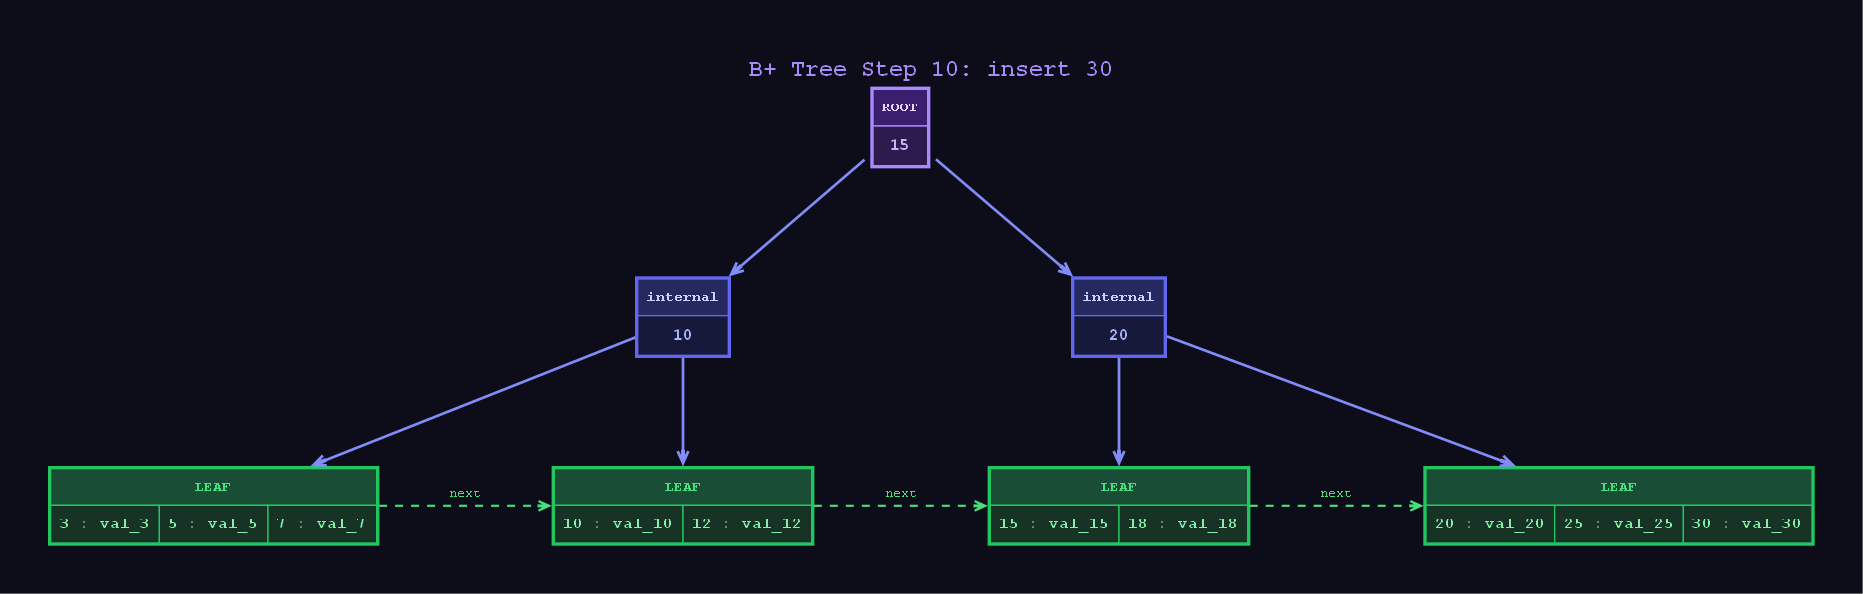


Step 11: insert 35
Split event 1: Leaf split (copy-up)
  child before split : [20, 25, 30]
  separator to parent: 25
  left after split   : [20]
  right after split  : [25, 30]
Level 0: I[15]
Level 1: I[10]  |  I[20, 25]
Level 2: L[3, 5, 7]  |  L[10, 12]  |  L[15, 18]  |  L[20]  |  L[25, 30, 35]
Leaf chain: [3, 5, 7] -> [10, 12] -> [15, 18] -> [20] -> [25, 30, 35]


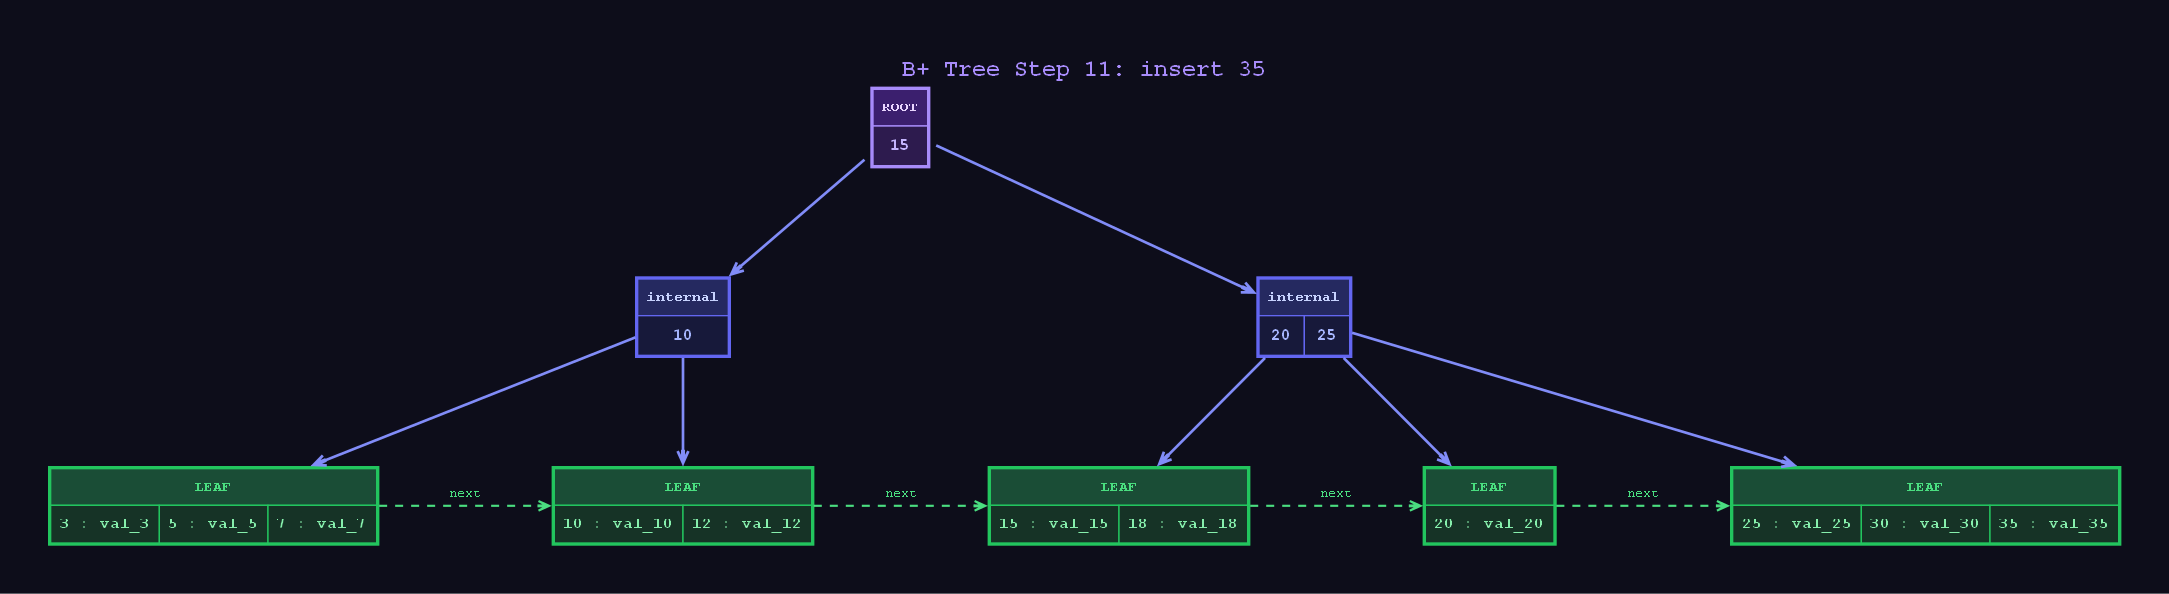


Step 12: insert 2
Split event 1: Leaf split (copy-up)
  child before split : [3, 5, 7]
  separator to parent: 5
  left after split   : [3]
  right after split  : [5, 7]
Level 0: I[15]
Level 1: I[5, 10]  |  I[20, 25]
Level 2: L[2, 3]  |  L[5, 7]  |  L[10, 12]  |  L[15, 18]  |  L[20]  |  L[25, 30, 35]
Leaf chain: [2, 3] -> [5, 7] -> [10, 12] -> [15, 18] -> [20] -> [25, 30, 35]


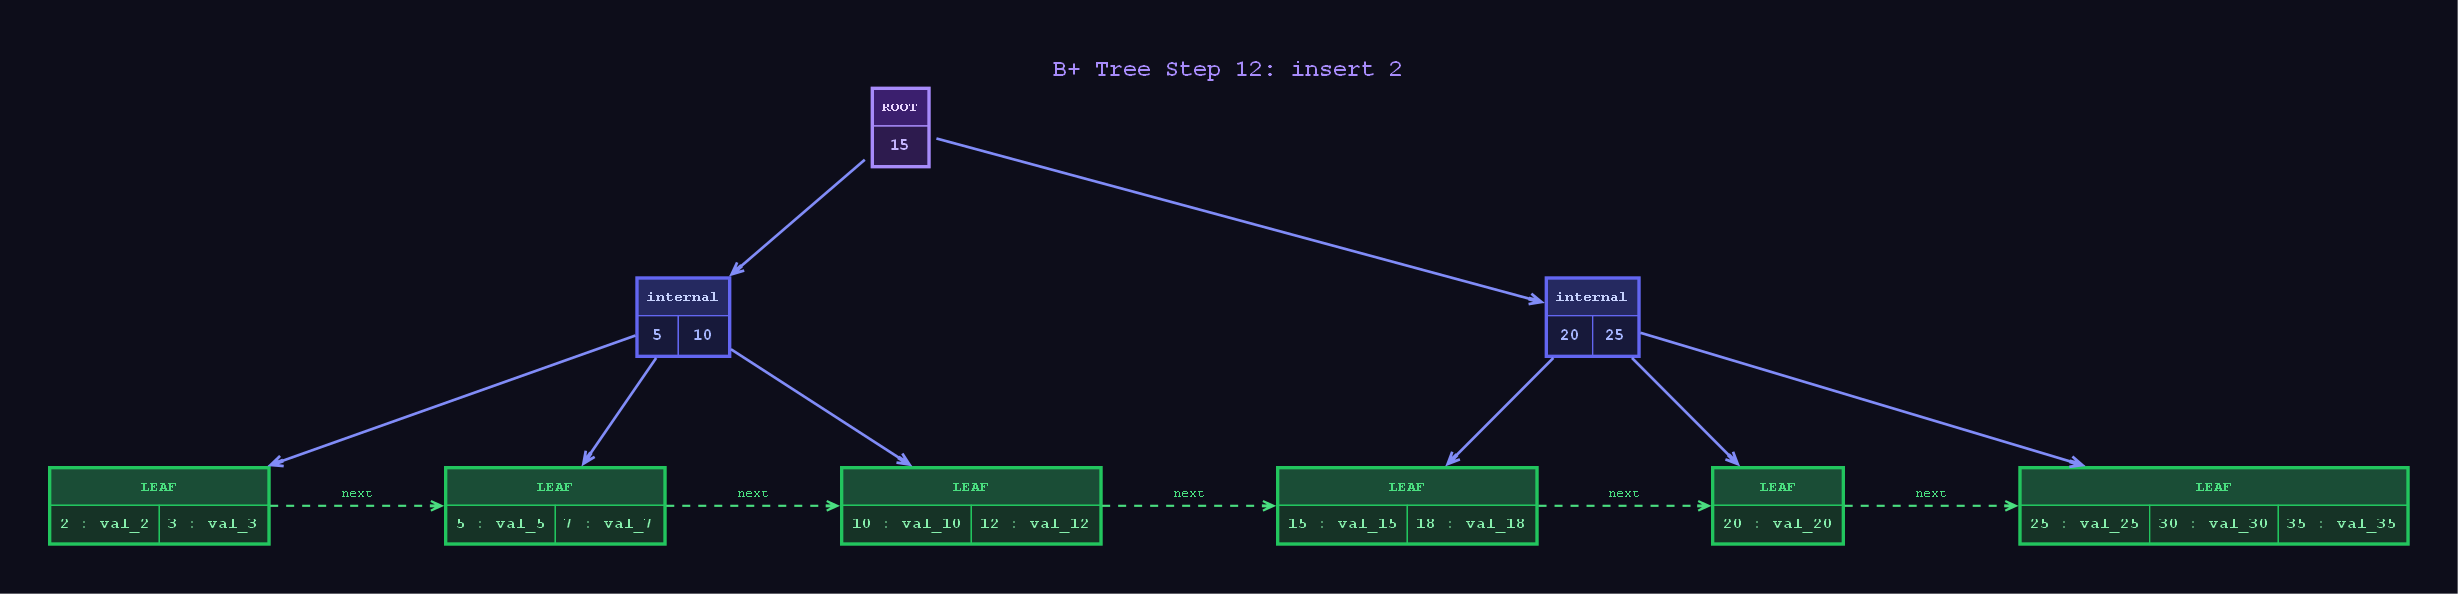


Step 13: insert 8
Split event: none
Level 0: I[15]
Level 1: I[5, 10]  |  I[20, 25]
Level 2: L[2, 3]  |  L[5, 7, 8]  |  L[10, 12]  |  L[15, 18]  |  L[20]  |  L[25, 30, 35]
Leaf chain: [2, 3] -> [5, 7, 8] -> [10, 12] -> [15, 18] -> [20] -> [25, 30, 35]


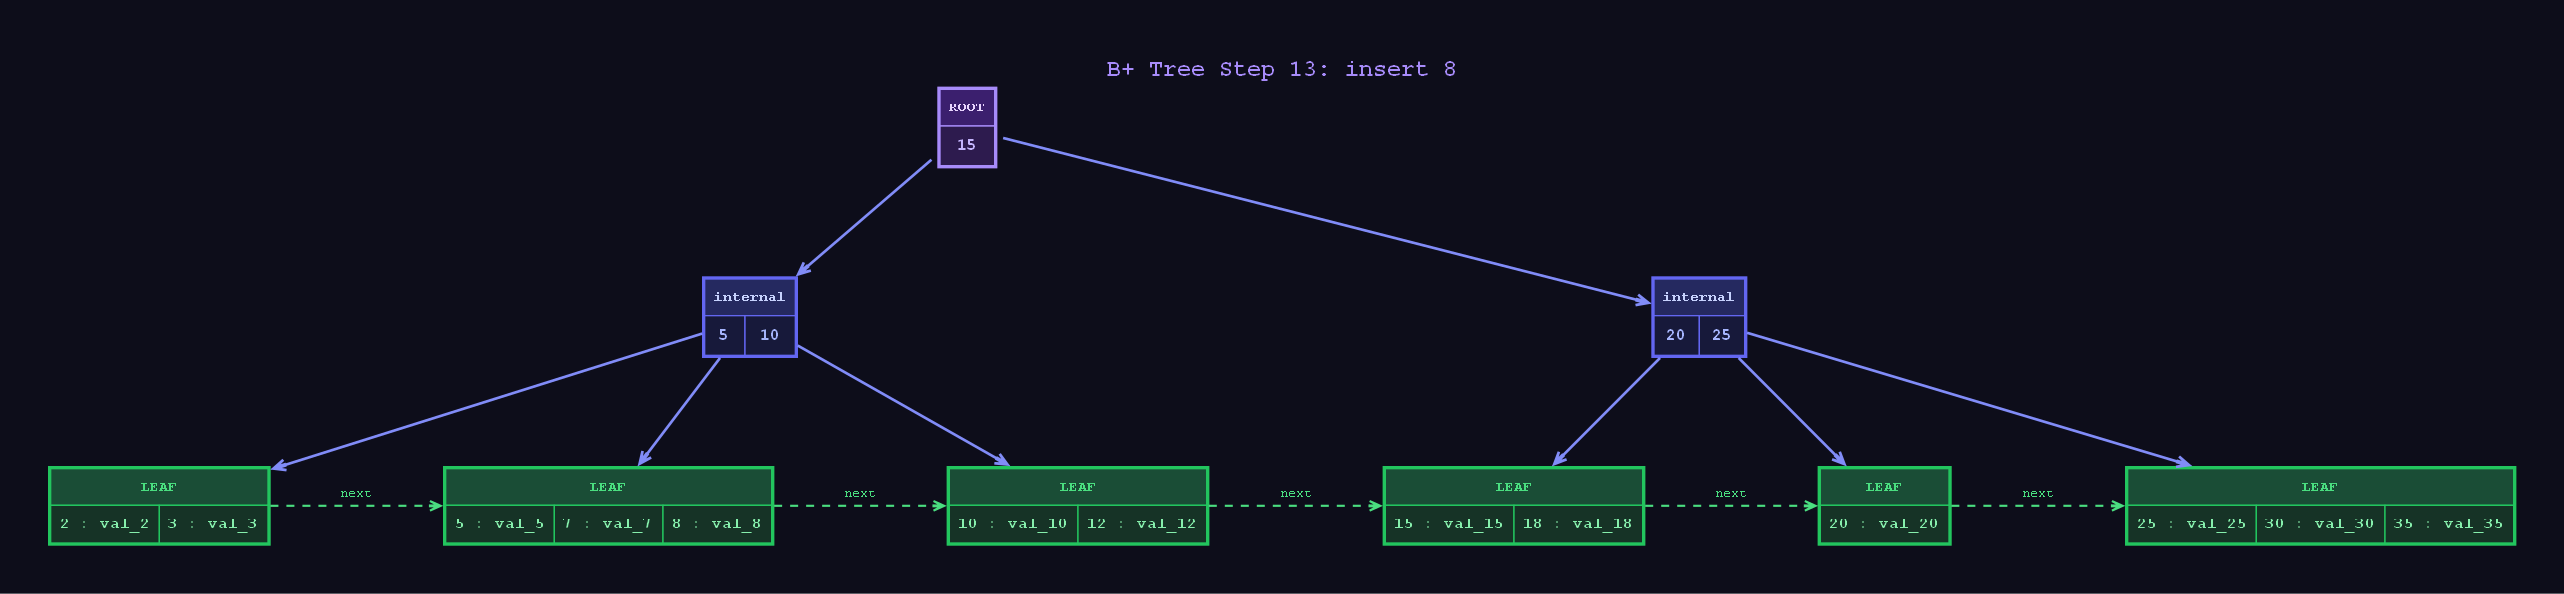


Step 14: insert 22
Split event: none
Level 0: I[15]
Level 1: I[5, 10]  |  I[20, 25]
Level 2: L[2, 3]  |  L[5, 7, 8]  |  L[10, 12]  |  L[15, 18]  |  L[20, 22]  |  L[25, 30, 35]
Leaf chain: [2, 3] -> [5, 7, 8] -> [10, 12] -> [15, 18] -> [20, 22] -> [25, 30, 35]


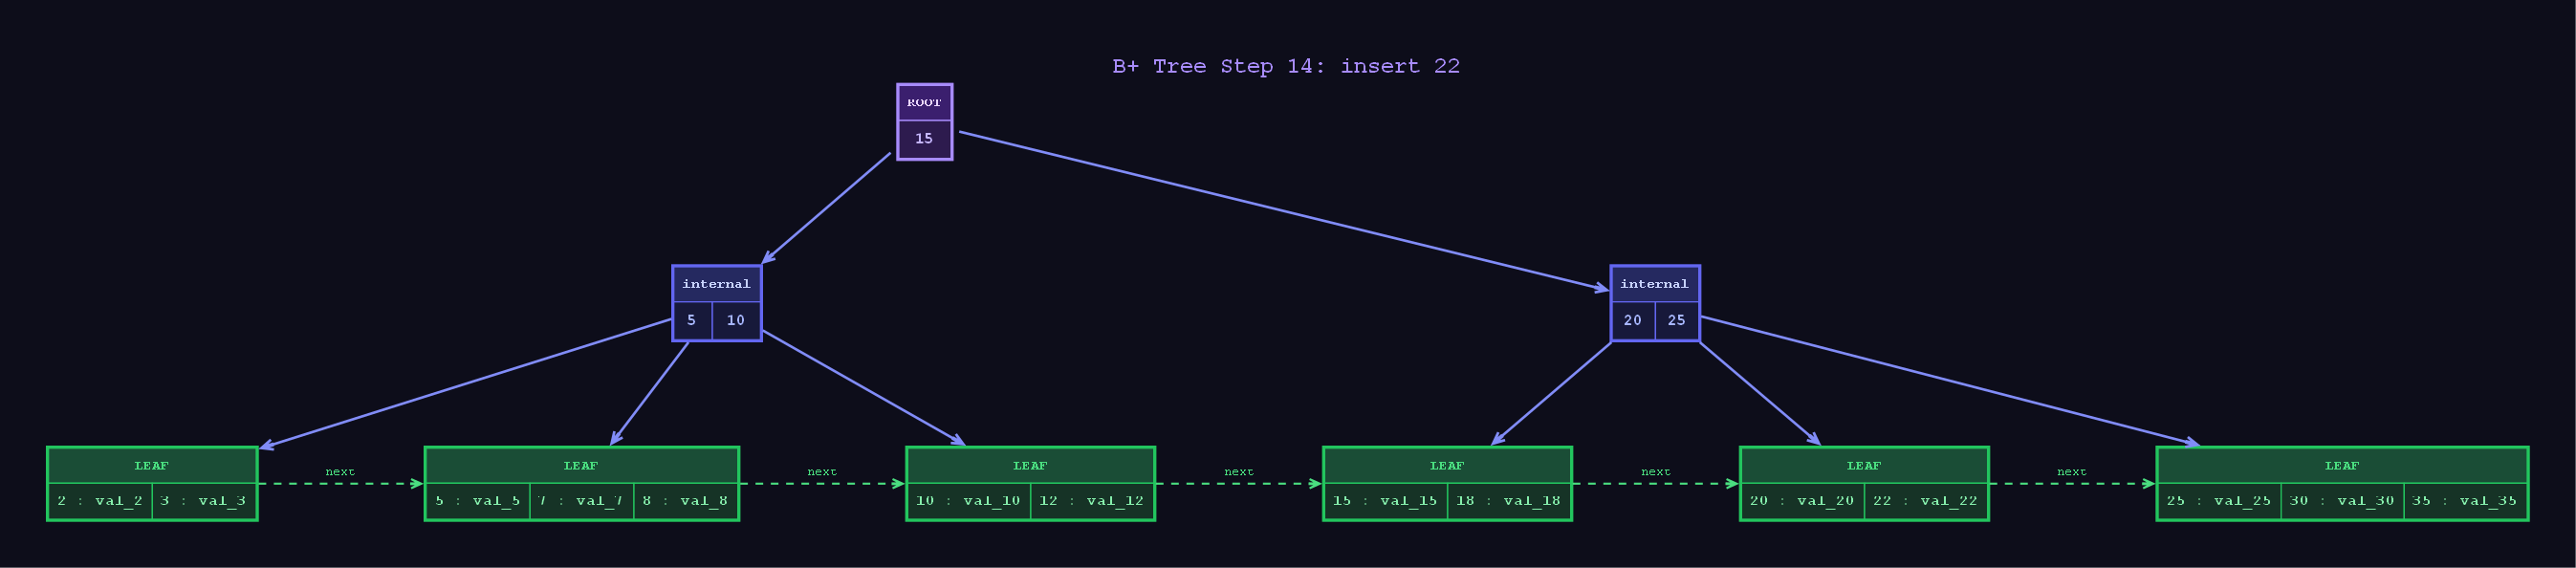


Done. All steps displayed inline.


In [3]:
sequence = [10, 20, 5, 15, 25, 3, 7, 12, 18, 30, 35, 2, 8, 22]
tree = TracedBPlusTree(order=4)

print('Running full construction trace...')
print('Sequence:', sequence)

for step, key in enumerate(sequence, 1):
    before_events = len(tree.trace_events)
    tree.insert(key, f"val_{key}")
    new_events = tree.trace_events[before_events:]

    print('\n' + '=' * 90)
    print(f"Step {step:02d}: insert {key}")

    if not new_events:
        print('Split event: none')
    else:
        for idx, event in enumerate(new_events, 1):
            event_type = 'Leaf split (copy-up)' if event['type'] == 'leaf-copy-up' else 'Internal split (promote-up)'
            print(f"Split event {idx}: {event_type}")
            print(f"  child before split : {event['child_before']}")
            print(f"  separator to parent: {event['separator_to_parent']}")
            print(f"  left after split   : {event['left_after']}")
            print(f"  right after split  : {event['right_after']}")

    print_tree_state(tree)
    show_inline_graph(tree, title=f"B+ Tree Step {step}: insert {key}")

print('\nDone. All steps displayed inline.')


##########################################################################################
Focused checkpoint: Step 4 (insert 15)
Event: Leaf split (copy-up)
  child before split : [5, 10, 20]
  separator to parent: 10
  left after split   : [5]
  right after split  : [10, 20]
Level 0: I[10]
Level 1: L[5]  |  L[10, 15, 20]
Leaf chain: [5] -> [10, 15, 20]


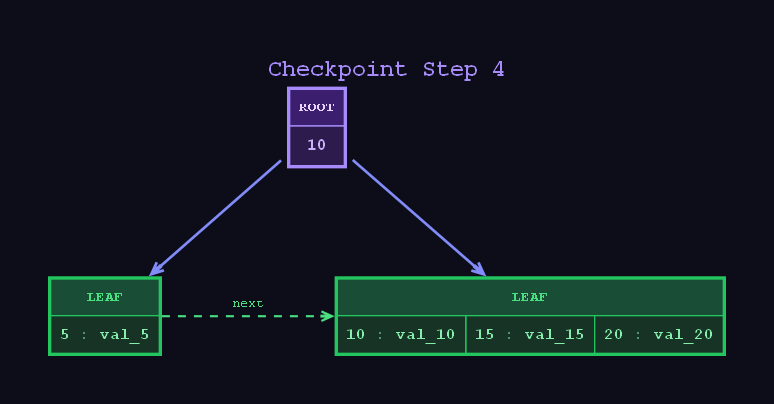


##########################################################################################
Focused checkpoint: Step 10 (insert 30)
Event: Internal split (promote-up)
  child before split : [10, 15, 20]
  separator to parent: 15
  left after split   : [10]
  right after split  : [20]
Level 0: I[15]
Level 1: I[10]  |  I[20]
Level 2: L[3, 5, 7]  |  L[10, 12]  |  L[15, 18]  |  L[20, 25, 30]
Leaf chain: [3, 5, 7] -> [10, 12] -> [15, 18] -> [20, 25, 30]


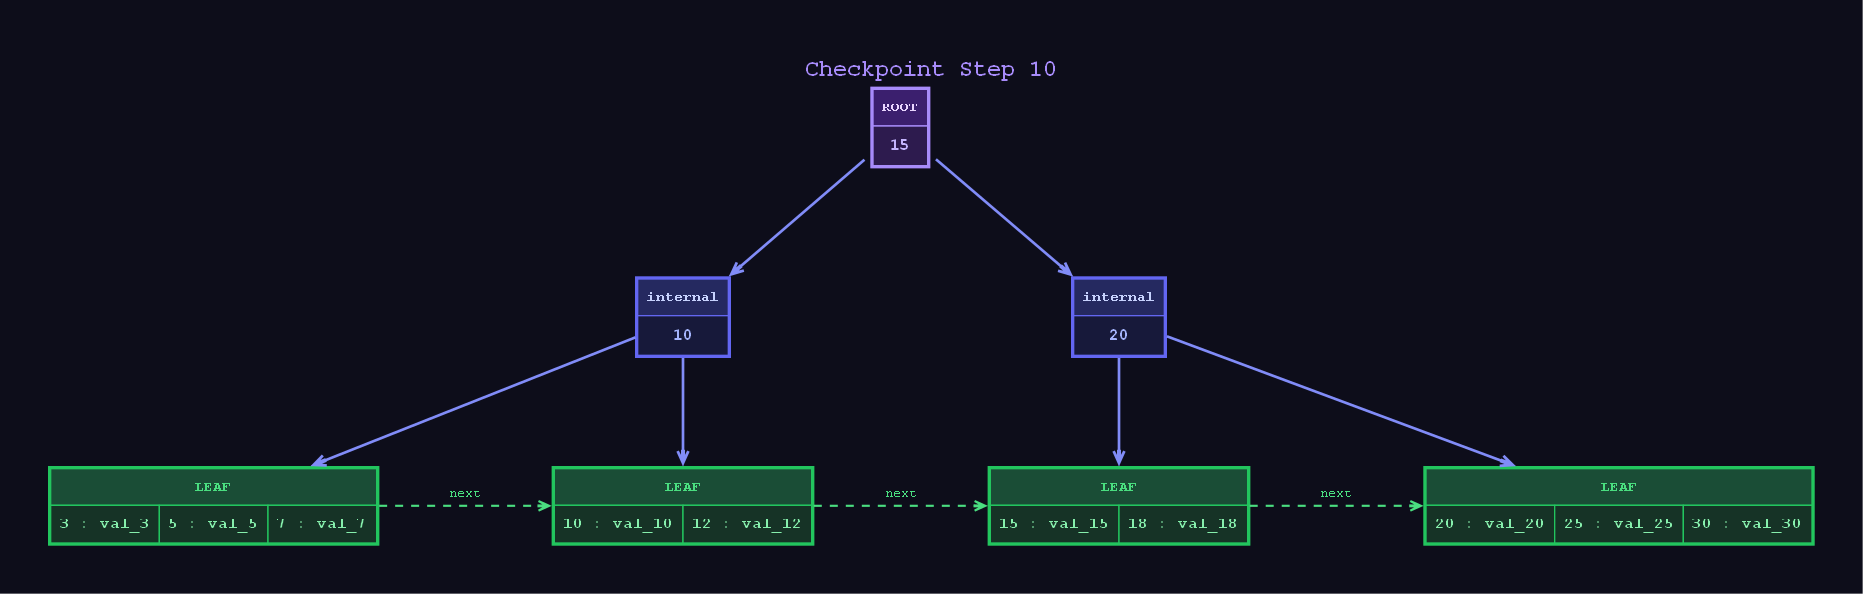

In [4]:
def replay_until(step_target, sequence):
    t = TracedBPlusTree(order=4)

    for i, k in enumerate(sequence, 1):
        before = len(t.trace_events)
        t.insert(k, f"val_{k}")

        if i == step_target:
            split_at_target = t.trace_events[before:]
            return t, k, split_at_target

    raise ValueError('step_target is out of range')


for target in [4, 10]:
    t, inserted_key, events = replay_until(target, sequence)

    print('\n' + '#' * 90)
    print(f"Focused checkpoint: Step {target} (insert {inserted_key})")

    if events:
        for event in events:
            title = 'Leaf split (copy-up)' if event['type'] == 'leaf-copy-up' else 'Internal split (promote-up)'
            print('Event:', title)
            print(f"  child before split : {event['child_before']}")
            print(f"  separator to parent: {event['separator_to_parent']}")
            print(f"  left after split   : {event['left_after']}")
            print(f"  right after split  : {event['right_after']}")
    else:
        print('No split happened at this step.')

    print_tree_state(t)
    show_inline_graph(t, title=f"Checkpoint Step {target}")